# 03 Model Training And Optimization
This notebook explains how the training script compares models and saves the best artifacts.
The backend expects the saved files in `ml_workspace/models`.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except Exception:
    sns = None
WORKSPACE = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
RESULTS = WORKSPACE / "results"

## Optional training command
Run this cell when you want to train fresh model artifacts.
Training can take time depending on dataset size.

In [2]:
import subprocess
#Uncomment when you want to retrain the model
#subprocess.run(["python", "scripts/train_github_dataset_model.py"], cwd=WORKSPACE, check=True)

In [3]:
comparison = pd.read_csv(RESULTS / "github_model_comparison.csv")
display(comparison)
metadata_path = RESULTS / "github_training_metadata.json"
metadata = json.loads(metadata_path.read_text(encoding="utf-8")) if metadata_path.exists() else {}
metadata

,model,best_params,threshold,validation_f1,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Logistic Regression,"{""classifier__solver"": ""liblinear"", ""classifie...",0.33,0.741935,0.625000,0.614379,0.895238,0.728682,0.704710,0.740376
1,Random Forest,"{""n_estimators"": 500, ""min_samples_split"": 5, ...",0.48,0.818018,0.776786,0.755376,0.892063,0.818049,0.855368,0.867208
2,XGBoost,"{""subsample"": 0.85, ""n_estimators"": 500, ""min_...",0.34,0.810036,0.782143,0.764384,0.885714,0.820588,0.854629,0.860806


{'best_model_name': 'XGBoost',
 'best_f1': 0.8205882352941176,
 'prediction_threshold': 0.34,
 'selected_features': ['nosi',
  'dit',
  'cbo',
  'rfc',
  'loc',
  'comparisonsQty',
  'returnQty',
  'wmc',
  'lcom',
  'totalMethods',
  'file_change_count',
  'file_bug_fix_count',
  'recent_file_change_count',
  'days_since_last_change',
  'last_change_lines_added',
  'last_change_lines_deleted',
  'last_change_churn',
  'last_change_file_count',
  'author_file_change_count'],
 'random_state': 42,
 'optimization': 'RandomizedSearchCV with 5-fold StratifiedKFold and validation threshold tuning',
 'feature_transformations': {'process_metric_compression': {'method': 'clip raw value to configured cap, apply log1p, then standard-scale process metrics using training-set mean/std',
   'reason': 'Reduce dominance of large process-history counts such as files changed together and place process metrics on a more comparable scale',
   'caps': {'file_change_count': 50,
    'file_bug_fix_count': 20,


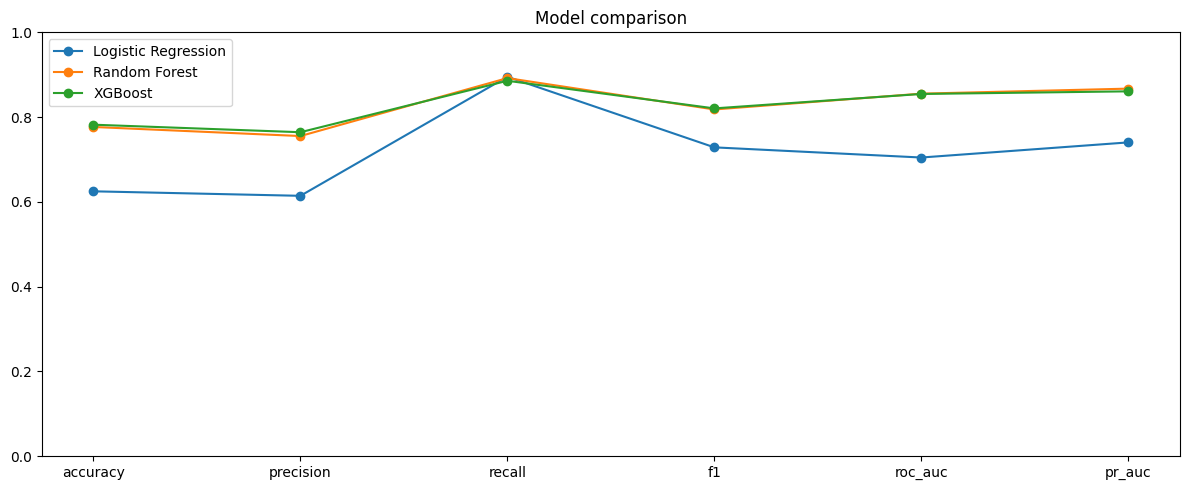

In [4]:
metrics = [column for column in ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"] if column in comparison.columns]
plot_data = comparison.melt(id_vars="model", value_vars=metrics, var_name="Metric", value_name="Score")
fig, ax = plt.subplots(figsize=(12, 5))
if sns:
    sns.barplot(data=plot_data, x="Metric", y="Score", hue="model", ax=ax)
else:
    for model_name, group in plot_data.groupby("model"):
        ax.plot(group["Metric"], group["Score"], marker="o", label=model_name)
    ax.legend()
ax.set_ylim(0, 1)
ax.set_title("Model comparison")
plt.tight_layout()
plt.show()